## Objective

Progressing through the NFL WR prediction model, to build off our baseline models, in this notebook we will begin to look at models using Random Forest as well as Gradient Boosting. From here we will evaluate each model and determine how to move forward with the best model for our particular situation

Dataset shape: (2127, 141)
Rows: 2,127
Columns: 141
player_id: True
receiving_yards: True
next_season_receiving_yards: True
Unique players: 619

Missing values:
shape: (1, 3)
┌───────────────────┬─────────────────────────┬────────────────┐
│ player_id_missing ┆ receiving_yards_missing ┆ target_missing │
│ ---               ┆ ---                     ┆ ---            │
│ u32               ┆ u32                     ┆ u32            │
╞═══════════════════╪═════════════════════════╪════════════════╡
│ 0                 ┆ 0                       ┆ 0              │
└───────────────────┴─────────────────────────┴────────────────┘
Training observations: 1,683
Testing observations: 444
Training players: 495
Testing players: 124
Player overlap: 0
Historical Persistence Baseline
MAE: 234.68
RMSE: 323.45
R-squared: 0.416
Predictor variables: 139
Target: next_season_receiving_yards
Grouping variable: player_id
Predictor definition verified.
X_train shape: (1683, 139)
X_test shape: (444, 139)
y_train

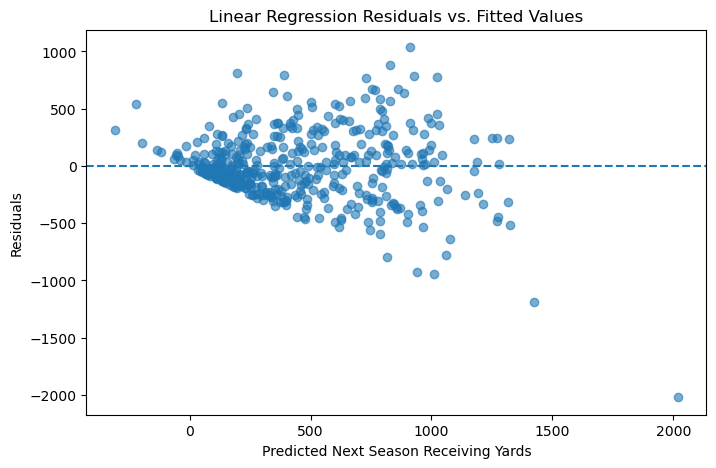

Breusch-Pagan Test
LM Statistic: 72.542850
LM p-value: 0.000000
F Statistic: 86.319350
F p-value: 0.000000
Jarque-Bera Test
JB Statistic: 467.985301
JB p-value: 0.000000
Skewness: -0.462
Kurtosis: 7.944


In [18]:
from pathlib import Path

notebook_path = Path.home() / "Desktop" / "06_Baseline_Models.ipynb"

%run "$notebook_path"

In [19]:
# Hyperparameter Tuning and Model Evaluation Imports

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import (
    RandomizedSearchCV
)

from sklearn.inspection import permutation_importance

In [20]:
# Initial Random Forest model

random_forest = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest.fit(
    X_train_raw,
    y_train
)

rf_predictions = random_forest.predict(
    X_test.to_numpy()
)

In [21]:
# Evaluate initial Random Forest

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Initial Random Forest Performance")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R-squared: {rf_r2:.3f}")

Initial Random Forest Performance
MAE: 218.10
RMSE: 289.78
R-squared: 0.531


In [22]:
# Random Forest training versus testing performance

rf_train_predictions = random_forest.predict(
    X_train_raw
)

rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_predictions
    )
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

print("Random Forest: Training vs Testing")
print()

print("Training Performance")
print(f"MAE: {rf_train_mae:.2f}")
print(f"RMSE: {rf_train_rmse:.2f}")
print(f"R-squared: {rf_train_r2:.3f}")

print()

print("Testing Performance")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R-squared: {rf_r2:.3f}")

Random Forest: Training vs Testing

Training Performance
MAE: 75.18
RMSE: 99.11
R-squared: 0.937

Testing Performance
MAE: 218.10
RMSE: 289.78
R-squared: 0.531


In [23]:
# Random Forest hyperparameter search space

rf_parameter_grid = {

    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        0.5,
        0.75,
        1.0,
        "sqrt"
    ]
}

In [24]:
# Random Forest grouped hyperparameter tuning

rf_group_cv = GroupKFold(
    n_splits=5
)

rf_random_search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=rf_parameter_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=rf_group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(
    X_train_raw,
    y_train,
    groups=groups_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20],
                                        'model__max_features': [0.5, 0.75, 1.0,
                                                                'sqrt'],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [25]:
# Best Random Forest tuning results

print("Best Random Forest Parameters")

for parameter, value in (
    rf_random_search
    .best_params_
    .items()
):

    print(
        f"{parameter}: {value}"
    )

print()

print(
    "Best Grouped CV RMSE:",
    round(
        -rf_random_search.best_score_,
        2
    )
)

Best Random Forest Parameters
model__n_estimators: 500
model__min_samples_split: 5
model__min_samples_leaf: 8
model__max_features: 1.0
model__max_depth: 10

Best Grouped CV RMSE: 263.7


In [26]:
# Evaluate tuned Random Forest on held-out test players

best_random_forest = (
    rf_random_search.best_estimator_
)

tuned_rf_predictions = (
    best_random_forest.predict(
        X_test.to_numpy()
    )
)

tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

print("Tuned Random Forest Performance")

print(
    f"MAE: {tuned_rf_mae:.2f}"
)

print(
    f"RMSE: {tuned_rf_rmse:.2f}"
)

print(
    f"R-squared: {tuned_rf_r2:.3f}"
)

Tuned Random Forest Performance
MAE: 214.69
RMSE: 287.30
R-squared: 0.539


In [27]:
# Tuned Random Forest training versus testing

tuned_rf_train_predictions = (
    best_random_forest.predict(
        X_train_raw
    )
)

tuned_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_rf_train_predictions
    )
)

tuned_rf_train_r2 = r2_score(
    y_train,
    tuned_rf_train_predictions
)

print("Tuned Random Forest: Training vs Testing")

print()

print("Training")
print(
    f"RMSE: {tuned_rf_train_rmse:.2f}"
)
print(
    f"R-squared: {tuned_rf_train_r2:.3f}"
)

print()

print("Testing")
print(
    f"RMSE: {tuned_rf_rmse:.2f}"
)
print(
    f"R-squared: {tuned_rf_r2:.3f}"
)

Tuned Random Forest: Training vs Testing

Training
RMSE: 188.21
R-squared: 0.774

Testing
RMSE: 287.30
R-squared: 0.539


In [28]:
# Initial Gradient Boosting model

gradient_boosting = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gradient_boosting.fit(
    X_train_raw,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_test.to_numpy()
)

In [29]:
# Evaluate initial Gradient Boosting model

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Initial Gradient Boosting Performance")

print(
    f"MAE: {gb_mae:.2f}"
)

print(
    f"RMSE: {gb_rmse:.2f}"
)

print(
    f"R-squared: {gb_r2:.3f}"
)

Initial Gradient Boosting Performance
MAE: 220.36
RMSE: 294.08
R-squared: 0.517


In [30]:
# Gradient Boosting hyperparameter search space

gb_parameter_grid = {

    "model__n_estimators": [
        50,
        100,
        200,
        300
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.10,
        0.20
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__subsample": [
        0.7,
        0.85,
        1.0
    ]
}

In [31]:
# Gradient Boosting grouped hyperparameter tuning

gb_group_cv = GroupKFold(
    n_splits=5
)

gb_random_search = RandomizedSearchCV(
    estimator=gradient_boosting,
    param_distributions=gb_parameter_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=gb_group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_random_search.fit(
    X_train_raw,
    y_train,
    groups=groups_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [50, 100, 200,
                                                                300],
                                        'model__subsample': [0.7, 0.85, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [32]:
# Best Gradient Boosting tuning results

print("Best Gradient Boosting Parameters")

for parameter, value in (
    gb_random_search
    .best_params_
    .items()
):

    print(
        f"{parameter}: {value}"
    )

print()

print(
    "Best Grouped CV RMSE:",
    round(
        -gb_random_search.best_score_,
        2
    )
)

Best Gradient Boosting Parameters
model__subsample: 0.85
model__n_estimators: 100
model__min_samples_split: 10
model__min_samples_leaf: 4
model__max_depth: 2
model__learning_rate: 0.1

Best Grouped CV RMSE: 261.36


In [33]:
# Evaluate tuned Gradient Boosting

best_gradient_boosting = (
    gb_random_search.best_estimator_
)

tuned_gb_predictions = (
    best_gradient_boosting.predict(
        X_test.to_numpy()
    )
)

tuned_gb_mae = mean_absolute_error(
    y_test,
    tuned_gb_predictions
)

tuned_gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_gb_predictions
    )
)

tuned_gb_r2 = r2_score(
    y_test,
    tuned_gb_predictions
)

print("Tuned Gradient Boosting Performance")

print(
    f"MAE: {tuned_gb_mae:.2f}"
)

print(
    f"RMSE: {tuned_gb_rmse:.2f}"
)

print(
    f"R-squared: {tuned_gb_r2:.3f}"
)

Tuned Gradient Boosting Performance
MAE: 214.35
RMSE: 286.68
R-squared: 0.541


In [34]:
# Tuned Gradient Boosting training versus testing

tuned_gb_train_predictions = (
    best_gradient_boosting.predict(
        X_train_raw
    )
)

tuned_gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_gb_train_predictions
    )
)

tuned_gb_train_r2 = r2_score(
    y_train,
    tuned_gb_train_predictions
)

print("Tuned Gradient Boosting: Training vs Testing")

print()

print("Training")
print(
    f"RMSE: {tuned_gb_train_rmse:.2f}"
)
print(
    f"R-squared: {tuned_gb_train_r2:.3f}"
)

print()

print("Testing")
print(
    f"RMSE: {tuned_gb_rmse:.2f}"
)
print(
    f"R-squared: {tuned_gb_r2:.3f}"
)

Tuned Gradient Boosting: Training vs Testing

Training
RMSE: 225.43
R-squared: 0.675

Testing
RMSE: 286.68
R-squared: 0.541


In [35]:
# Compare all models on held-out test players

model_comparison = pl.DataFrame({

    "Model": [
        "Historical Persistence",
        "Linear Regression",
        "Initial Random Forest",
        "Tuned Random Forest",
        "Initial Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE": [
        persistence_mae,
        linear_mae,
        rf_mae,
        tuned_rf_mae,
        gb_mae,
        tuned_gb_mae
    ],

    "RMSE": [
        persistence_rmse,
        linear_rmse,
        rf_rmse,
        tuned_rf_rmse,
        gb_rmse,
        tuned_gb_rmse
    ],

    "R_squared": [
        persistence_r2,
        linear_r2,
        rf_r2,
        tuned_rf_r2,
        gb_r2,
        tuned_gb_r2
    ]

})
model_comparison.sort(
    "RMSE"
)

Model,MAE,RMSE,R_squared
str,f64,f64,f64
"""Tuned Gradient Boosting""",214.346375,286.676695,0.540909
"""Tuned Random Forest""",214.686016,287.297478,0.538919
"""Initial Random Forest""",218.101239,289.778135,0.530922
"""Initial Gradient Boosting""",220.36496,294.079163,0.516894
"""Linear Regression""",220.521498,302.600344,0.488491
"""Historical Persistence""",234.677928,323.453183,0.415564


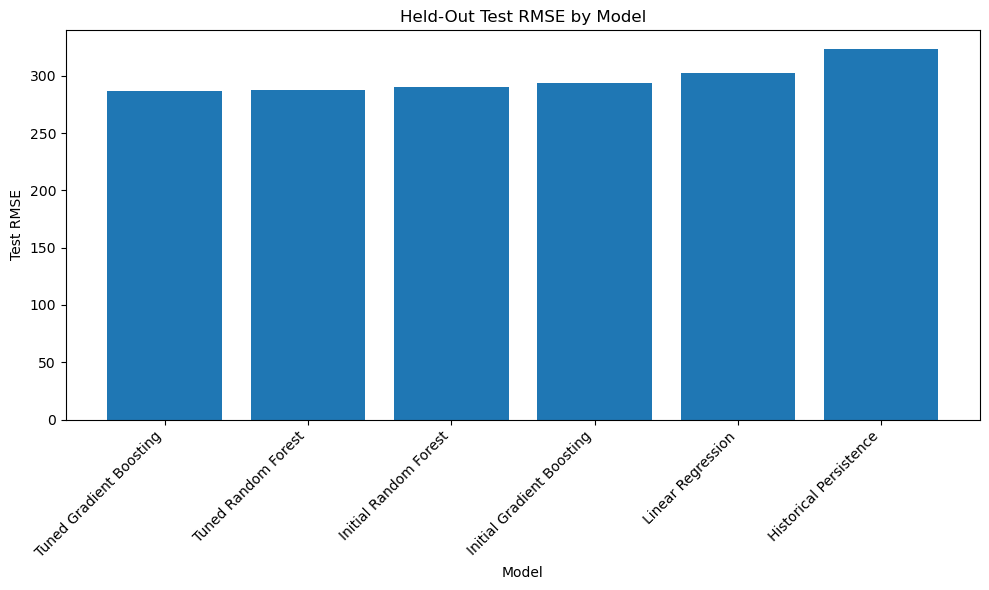

In [36]:
# Compare test RMSE across models

comparison_pd = (
    model_comparison
    .sort("RMSE")
    .to_pandas()
)

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_pd["Model"],
    comparison_pd["RMSE"]
)

plt.ylabel(
    "Test RMSE"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Held-Out Test RMSE by Model"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [37]:
# Select best tuned nonlinear model based on test RMSE

if tuned_rf_rmse <= tuned_gb_rmse:

    best_model_name = (
        "Tuned Random Forest"
    )

    best_model = (
        best_random_forest
    )

    best_predictions = (
        tuned_rf_predictions
    )

else:

    best_model_name = (
        "Tuned Gradient Boosting"
    )

    best_model = (
        best_gradient_boosting
    )

    best_predictions = (
        tuned_gb_predictions
    )

print(
    "Best tuned nonlinear model:",
    best_model_name
)

Best tuned nonlinear model: Tuned Gradient Boosting


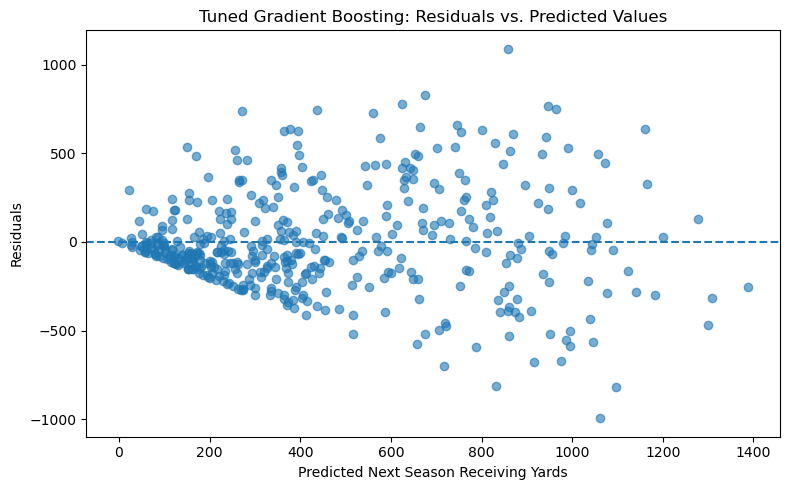

In [38]:
# Residual plot for best tuned nonlinear model

best_residuals = (
    y_test - best_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    best_predictions,
    best_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Next Season Receiving Yards"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    f"{best_model_name}: Residuals vs. Predicted Values"
)

plt.tight_layout()

plt.show()

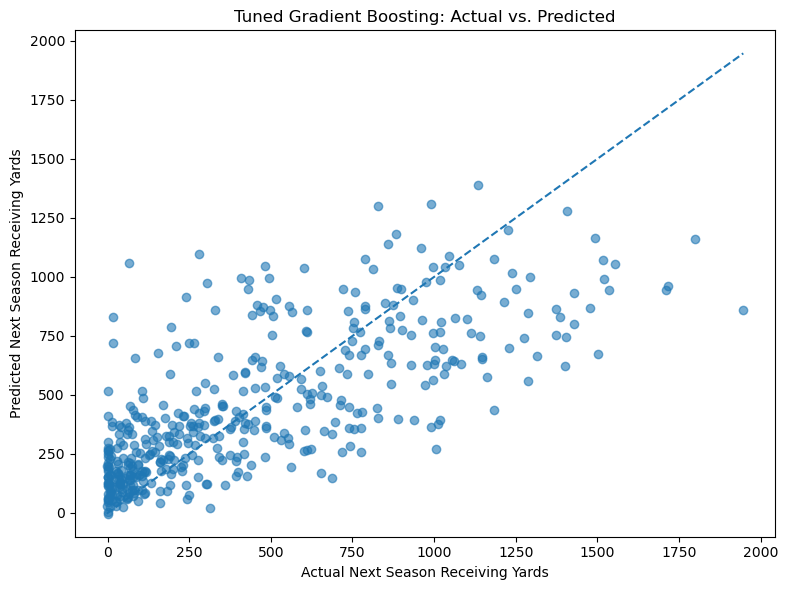

In [39]:
# Actual versus predicted receiving yards

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

minimum_value = min(
    y_test.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Next Season Receiving Yards"
)

plt.ylabel(
    "Predicted Next Season Receiving Yards"
)

plt.title(
    f"{best_model_name}: Actual vs. Predicted"
)

plt.tight_layout()

plt.show()

In [40]:
# Permutation importance for best tuned model

permutation_results = permutation_importance(
    best_model,
    X_test.to_numpy(),
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pl.DataFrame({
    "Feature":
        predictor_columns,
    "Importance":
        permutation_results.importances_mean
})

feature_importance = (
    feature_importance
    .sort(
        "Importance",
        descending=True
    )
)

feature_importance.head(20)

Feature,Importance
str,f64
"""receiving_yards""",65.982536
"""season""",14.689242
"""last_season""",14.351056
"""years_of_experience""",7.222142
"""receiving_first_downs""",6.922077
…,…
"""jersey_number""",0.507842
"""receiving_16""",0.501914
"""punt_return_yards""",0.471837


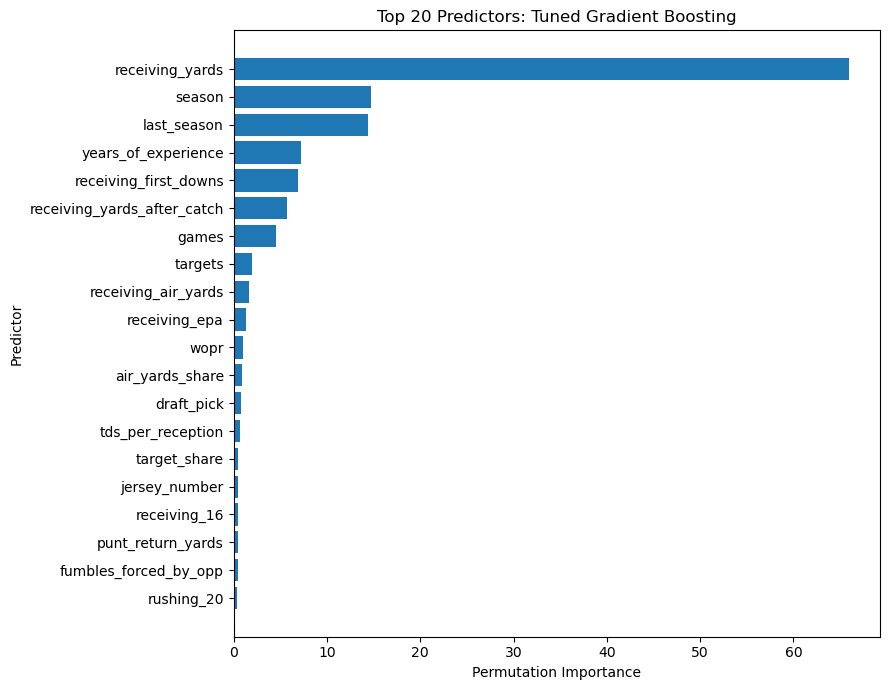

Exception ignored in: <function ResourceTracker.__del__ at 0x107c65d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [41]:
# Plot top 20 permutation importance variables

top_features = (
    feature_importance
    .head(20)
    .sort("Importance")
    .to_pandas()
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Permutation Importance"
)

plt.ylabel(
    "Predictor"
)

plt.title(
    f"Top 20 Predictors: {best_model_name}"
)

plt.tight_layout()

plt.show()

## Results

Moving forward we will continue to work with Tuned Gradient Boosting. This is just some early analysis on these models and the next step is to make changes to improve the model. Clearly, work can be done as Receiving Yards, Season, and Last Season shouldn't be considered since we are trying to predict receiving yards, and season is fixed to last season so we need to remove these variables